In [1]:
import os
import PIL
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F

from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

from d_vae import GumbelQuantizer, TinnyDVAE

In [2]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'Device is {device}')

Device is cuda


In [3]:
PATH_TO_PHOTOS = '../archive/lfw-deepfunneled'

paths = []
for dirpath, _, filenames in os.walk(PATH_TO_PHOTOS):
    for fname in filenames:
        if fname.endswith('.jpg'):
            paths.append(os.path.join(dirpath, fname))

all_photos = []
for path in tqdm(paths):
    with open(path, 'rb') as f:
        image = np.array(Image.open(f).convert('RGB'))[80:-80, 80:-80]
        image = np.array(Image.fromarray(image).resize((64, 64), Image.Resampling.LANCZOS))
        all_photos.append(image)

print(f'Photos uploaded: {len(all_photos)}')

100%|██████████| 13233/13233 [00:10<00:00, 1260.86it/s]

Photos uploaded: 13233


In [4]:
n_epochs = 100
model = TinnyDVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss(reduction='sum')

train_photos, val_photos = train_test_split(all_photos, train_size=0.9, shuffle=True)
train_loader = torch.utils.data.DataLoader(train_photos, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_photos, batch_size=32)

TAU_START, TAU_MIN, ANNEAL = 1.0, 0.1, 0.97  # temperature schedule
EVAL_TAU = TAU_MIN  # near-discrete codes for eval/reconstruction

In [5]:
train_losses, val_losses = [], []

for epoch in tqdm(range(n_epochs)):
    temperature = max(TAU_MIN, TAU_START * (ANNEAL ** epoch))  # anneal high -> low
    
    model.train()
    epoch_train_losses = []
    for batch in train_loader:
        batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32)/255
        
        optimizer.zero_grad()
        reconstruction = model(batch, temperature=temperature)
        loss = criterion(batch, reconstruction)
        loss.backward()
        optimizer.step()
        
        epoch_train_losses.append(loss.item())
    
    train_losses.append(np.mean(epoch_train_losses))

    model.eval()
    epoch_val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32)/255
            
            reconstruction = model(batch, temperature=EVAL_TAU)  # fixed low temp
            loss = criterion(batch, reconstruction)

            epoch_val_losses.append(loss.item())

    val_losses.append(np.mean(epoch_val_losses))

100%|██████████| 100/100 [06:26<00:00,  3.86s/it]


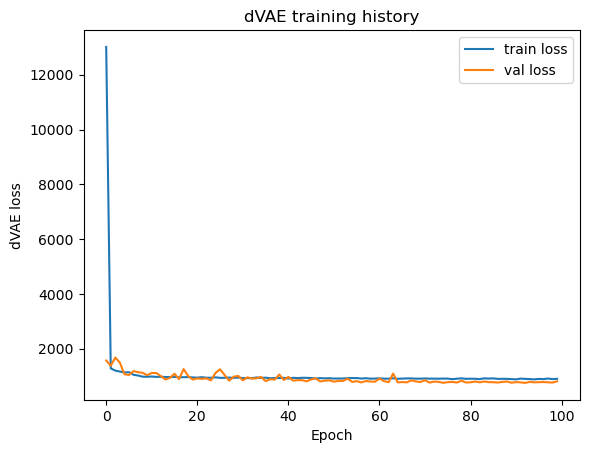

In [6]:
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("dVAE loss")
plt.title("dVAE training history")
plt.show()

## Reconstruction


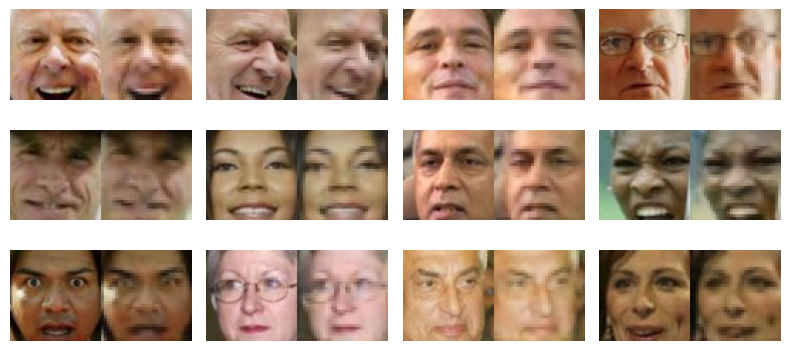

In [7]:
model.eval()
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device).permute(0, 3, 1, 2).to(torch.float32)/255
        reconstruction = model(batch, temperature=EVAL_TAU)
        break

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(8, 4))
for idx, ax in enumerate(axes.flatten()):
    img = np.concatenate([
        batch[idx].cpu().permute(1, 2, 0),
        reconstruction[idx].cpu().permute(1, 2, 0).clip(0, 1)
    ], axis=1)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()